# Exploración del subcorpus de cuartetos separado por movimientos

Este notebook analiza el archivo:

```text
quartet_subcorpus_all_movements.csv
```

La unidad de cada fila es un **movimiento individual** de un cuarteto de cuerda.
Cada fila contiene cuatro secuencias monofónicas de alturas MIDI, en el orden:

1. violín I;
2. violín II;
3. viola;
4. cello.

## Preguntas

- ¿Cuántos movimientos, obras, compositores y periodos contiene el corpus?
- ¿Qué piezas están presentes?
- ¿Todas las obras contienen el mismo número de movimientos?
- ¿Qué longitud tiene cada voz en cada movimiento?
- ¿Cómo varía la longitud entre movimientos, instrumentos, compositores y periodos?
- ¿Qué movimientos son especialmente cortos o largos?
- ¿Cómo reconstruir una obra completa preservando las fronteras entre movimientos?
- ¿Cómo escuchar una sola voz de un movimiento?

In [3]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Audio, FileLink

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

SEARCH_DIRS = [Path.cwd(), Path("/mnt/data")]

def find_latest_csv(pattern):
    candidates = []
    for directory in SEARCH_DIRS:
        candidates.extend(directory.glob(pattern))

    candidates = sorted(
        {path.resolve() for path in candidates if path.exists()},
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    if not candidates:
        raise FileNotFoundError(
            f"No se encontró un CSV compatible con {pattern!r} "
            f"en {[str(directory) for directory in SEARCH_DIRS]}."
        )

    return candidates[0]

csv_path = find_latest_csv("cvs/quartet_subcorpus_all_movements*.csv")
print("Archivo utilizado:", csv_path)

Archivo utilizado: D:\La formula secreta de la cangreburger\Documentos\uaem\octavo semestre\Tesis\multivoice\cvs\quartet_subcorpus_all_movements.csv


In [4]:
df = pd.read_csv(csv_path)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
display(pd.DataFrame({
    "columna": df.columns,
    "tipo": [str(dtype) for dtype in df.dtypes],
    "nulos": [int(df[column].isna().sum()) for column in df.columns],
}))

Filas: 116
Columnas: 24


,columna,tipo,nulos
0,work_id,object,0
1,composer,object,0
2,composer_canonical,object,0
3,period,object,0
4,genre,object,0
5,instrumentation,object,0
6,catalogue,object,0
7,work_title,object,0
8,corpus_group,object,0
9,analysis_status,object,0


## 2. Qué contiene realmente el archivo

En este corpus:

- una fila representa un movimiento;
- `work_id` identifica la obra;
- `movement_no` identifica el orden del movimiento;
- `filename` identifica el MIDI del movimiento;
- `voices_pitches` contiene cuatro listas de alturas MIDI;
- `min_len`, `max_len` y `mean_len` resumen las longitudes de las cuatro voces.

Se comprobará que la estructura real coincida con esta descripción.

In [5]:
basic_summary = pd.DataFrame({
    "propiedad": [
        "Filas / movimientos",
        "Obras únicas",
        "Compositores",
        "Periodos",
        "Grupos del corpus",
        "Mínimo de min_len",
        "Mediana de min_len",
        "Máximo de min_len",
        "Mínimo de max_len",
        "Mediana de max_len",
        "Máximo de max_len",
    ],
    "valor": [
        len(df),
        df["work_id"].nunique(),
        df["composer_canonical"].nunique(),
        df["period"].nunique(),
        df["corpus_group"].nunique(),
        int(df["min_len"].min()),
        float(df["min_len"].median()),
        int(df["min_len"].max()),
        int(df["max_len"].min()),
        float(df["max_len"].median()),
        int(df["max_len"].max()),
    ],
})

display(basic_summary)

,propiedad,valor
0,Filas / movimientos,116.0
1,Obras únicas,29.0
2,Compositores,8.0
3,Periodos,5.0
4,Grupos del corpus,3.0
5,Mínimo de min_len,114.0
6,Mediana de min_len,583.0
7,Máximo de min_len,1607.0
8,Mínimo de max_len,230.0
9,Mediana de max_len,931.0


## 3. Validación de `voices_pitches`

Para cada movimiento se comprobará:

1. que el JSON sea válido;
2. que existan exactamente cuatro voces;
3. que cada valor sea una altura MIDI entre 0 y 127;
4. que las longitudes calculadas coincidan con `min_len`, `max_len` y `mean_len`;
5. que los roles sean `vln I|vln II|viola|cello`.

In [6]:
VOICE_ROLES = ["vln_I", "vln_II", "viola", "cello"]
EXPECTED_ROLE_STRING = "vln I|vln II|viola|cello"

def parse_voices(value, row_label):
    try:
        voices = json.loads(value)
    except Exception as exc:
        raise ValueError(f"JSON inválido en {row_label}: {exc}") from exc

    if not isinstance(voices, list) or len(voices) != 4:
        raise ValueError(
            f"{row_label}: se esperaban cuatro voces y se encontraron "
            f"{len(voices) if isinstance(voices, list) else 'un objeto no válido'}."
        )

    parsed = []
    for voice_index, voice in enumerate(voices):
        if not isinstance(voice, list):
            raise TypeError(f"{row_label}, voz {voice_index}: no es una lista.")

        converted = []
        for pitch in voice:
            if not isinstance(pitch, (int, float)):
                raise TypeError(
                    f"{row_label}, voz {voice_index}: valor no numérico {pitch!r}."
                )
            pitch = int(round(pitch))
            if not 0 <= pitch <= 127:
                raise ValueError(
                    f"{row_label}, voz {voice_index}: altura MIDI fuera de rango: {pitch}."
                )
            converted.append(pitch)

        parsed.append(converted)

    return parsed

df["voices"] = [
    parse_voices(value, f"{work_id}, movimiento {movement_no}")
    for value, work_id, movement_no in zip(
        df["voices_pitches"],
        df["work_id"],
        df["movement_no"],
    )
]

validation_rows = []

for index, row in df.iterrows():
    lengths = [len(voice) for voice in row["voices"]]

    validation_rows.append({
        "row_index": index,
        "work_id": row["work_id"],
        "movement_no": int(row["movement_no"]),
        "n_voices_calculated": len(row["voices"]),
        "roles_valid": row["roles"] == EXPECTED_ROLE_STRING,
        "min_len_valid": min(lengths) == int(row["min_len"]),
        "max_len_valid": max(lengths) == int(row["max_len"]),
        "mean_len_valid": np.isclose(
            np.mean(lengths),
            float(row["mean_len"]),
            atol=0.11,
        ),
    })

validation = pd.DataFrame(validation_rows)
validation["all_valid"] = validation[
    ["roles_valid", "min_len_valid", "max_len_valid", "mean_len_valid"]
].all(axis=1)

display(validation["all_valid"].value_counts().rename("n_filas").to_frame())

assert validation["all_valid"].all(), "Hay filas que no superaron la validación."
print("Todas las filas superaron la validación.")

,n_filas
all_valid,
True,116


Todas las filas superaron la validación.


## 4. Obras, compositores y periodos

El corpus contiene:

### Núcleo clásico

- Haydn: seis cuartetos Op.20;
- Mozart: seis cuartetos dedicados a Haydn;
- Beethoven: seis cuartetos Op.18.

### Extensión romántica

- Schumann: tres cuartetos Op.41;
- Brahms: tres cuartetos;
- Dvořák: tres cuartetos.

### Casos externos

- Debussy: Cuarteto Op.10;
- Shostakovich: Cuarteto No.1, Op.49.

Beethoven se conserva como
`Classical / transitional` porque Op.18 parte del lenguaje clásico, pero permite
examinar cambios en la distribución de material entre las cuatro voces.

In [7]:
works_table = (
    df[[
        "work_id",
        "composer_canonical",
        "period",
        "catalogue",
        "work_title",
        "corpus_group",
        "analysis_status",
        "instrumentation",
        "edition_source",
        "is_complete_work_in_selected_edition",
    ]]
    .drop_duplicates("work_id")
    .sort_values(["corpus_group", "composer_canonical", "catalogue"])
    .reset_index(drop=True)
)

display(works_table)

composer_summary = (
    works_table.groupby(
        ["corpus_group", "composer_canonical", "period"],
        dropna=False,
    )
    .size()
    .rename("n_obras")
    .reset_index()
)

composer_summary["n_movimientos"] = composer_summary["n_obras"] * 4
display(composer_summary)

,work_id,composer_canonical,period,catalogue,work_title,corpus_group,analysis_status,instrumentation,edition_source,is_complete_work_in_selected_edition
0,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,include,2vn-va-vc,simonetto,True
1,haydn_op20_no2,Joseph Haydn,Classical,Op. 20 No. 2,String Quartet Op. 20 No. 2,classical_core,include,2vn-va-vc,simonetto,True
2,haydn_op20_no3,Joseph Haydn,Classical,Op. 20 No. 3,String Quartet Op. 20 No. 3,classical_core,include,2vn-va-vc,simonetto,True
3,haydn_op20_no4,Joseph Haydn,Classical,Op. 20 No. 4,String Quartet Op. 20 No. 4,classical_core,include,2vn-va-vc,simonetto,True
4,haydn_op20_no5,Joseph Haydn,Classical,Op. 20 No. 5,String Quartet Op. 20 No. 5,classical_core,include,2vn-va-vc,simonetto,True
5,haydn_op20_no6,Joseph Haydn,Classical,Op. 20 No. 6,String Quartet Op. 20 No. 6,classical_core,include,2vn-va-vc,simonetto,True
6,beethoven_op18_no1,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 1,String Quartet Op. 18 No. 1,classical_core,include,2vn-va-vc,edwards,True
7,beethoven_op18_no2,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 2,String Quartet Op. 18 No. 2,classical_core,include,2vn-va-vc,edwards,True
8,beethoven_op18_no3,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 3,String Quartet Op. 18 No. 3,classical_core,include,2vn-va-vc,edwards,True
9,beethoven_op18_no4,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 4,String Quartet Op. 18 No. 4,classical_core,include,2vn-va-vc,edwards,True


,corpus_group,composer_canonical,period,n_obras,n_movimientos
0,classical_core,Joseph Haydn,Classical,6,24
1,classical_core,Ludwig van Beethoven,Classical / transitional,6,24
2,classical_core,Wolfgang Amadeus Mozart,Classical,6,24
3,modern_case_study,Claude Debussy,Late 19th century / fin-de-siècle,1,4
4,modern_case_study,Dmitri Shostakovich,20th century,1,4
5,romantic_extension,Antonín Dvořák,Romantic,3,12
6,romantic_extension,Johannes Brahms,Romantic,3,12
7,romantic_extension,Robert Schumann,Romantic,3,12


,n_obras
period,
20th century,1
Late 19th century / fin-de-siècle,1
Classical / transitional,6
Romantic,9
Classical,12


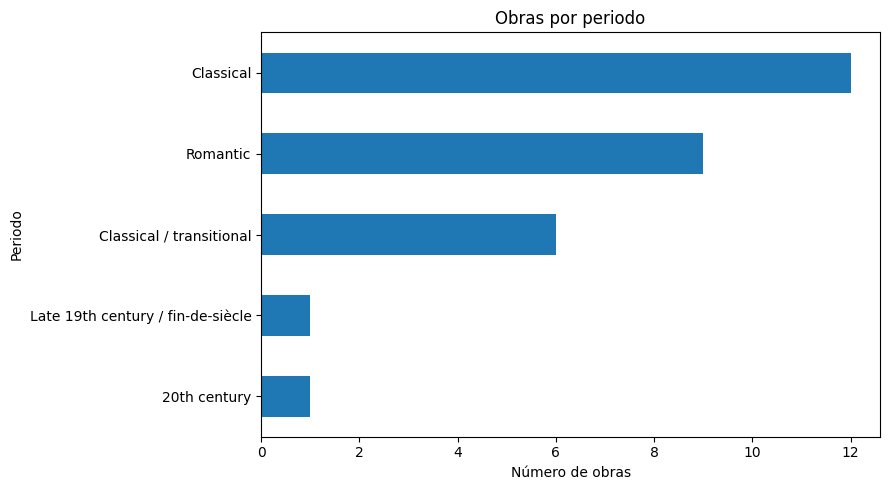

In [8]:
period_summary = (
    works_table.groupby("period")
    .size()
    .sort_values()
    .rename("n_obras")
    .to_frame()
)

display(period_summary)

plt.figure(figsize=(9, 5))
period_summary["n_obras"].plot(kind="barh")
plt.xlabel("Número de obras")
plt.ylabel("Periodo")
plt.title("Obras por periodo")
plt.tight_layout()
plt.show()

## 5. ¿Todas las obras están completas?

Para este archivo se espera:

- cuatro filas por `work_id`;
- movimientos numerados 1, 2, 3 y 4;
- `file_unit == "movement"`;
- edición seleccionada marcada como completa.

La validación siguiente detecta automáticamente obras incompletas, movimientos
duplicados o números ausentes.

In [9]:
def movement_signature(series):
    return tuple(sorted(int(value) for value in series))

work_completeness = (
    df.groupby([
        "work_id",
        "composer_canonical",
        "catalogue",
        "work_title",
        "corpus_group",
    ])
    .agg(
        n_rows=("movement_no", "size"),
        n_unique_movements=("movement_no", "nunique"),
        movement_numbers=("movement_no", movement_signature),
        all_rows_are_movements=("file_unit", lambda s: bool((s == "movement").all())),
        selected_edition_complete=(
            "is_complete_work_in_selected_edition",
            "all",
        ),
        n_editions=("edition_source", "nunique"),
    )
    .reset_index()
)

work_completeness["has_movements_1_to_4"] = (
    work_completeness["movement_numbers"] == (1, 2, 3, 4)
)
work_completeness["is_structurally_complete"] = (
    (work_completeness["n_rows"] == 4)
    & (work_completeness["n_unique_movements"] == 4)
    & work_completeness["has_movements_1_to_4"]
    & work_completeness["all_rows_are_movements"]
    & work_completeness["selected_edition_complete"]
    & (work_completeness["n_editions"] == 1)
)

display(work_completeness)
assert work_completeness["is_structurally_complete"].all()

,work_id,composer_canonical,catalogue,work_title,corpus_group,n_rows,n_unique_movements,movement_numbers,all_rows_are_movements,selected_edition_complete,n_editions,has_movements_1_to_4,is_structurally_complete
0,beethoven_op18_no1,Ludwig van Beethoven,Op. 18 No. 1,String Quartet Op. 18 No. 1,classical_core,4,4,"(1, 2, 3, 4)",True,True,1,True,True
1,beethoven_op18_no2,Ludwig van Beethoven,Op. 18 No. 2,String Quartet Op. 18 No. 2,classical_core,4,4,"(1, 2, 3, 4)",True,True,1,True,True
2,beethoven_op18_no3,Ludwig van Beethoven,Op. 18 No. 3,String Quartet Op. 18 No. 3,classical_core,4,4,"(1, 2, 3, 4)",True,True,1,True,True
3,beethoven_op18_no4,Ludwig van Beethoven,Op. 18 No. 4,String Quartet Op. 18 No. 4,classical_core,4,4,"(1, 2, 3, 4)",True,True,1,True,True
4,beethoven_op18_no5,Ludwig van Beethoven,Op. 18 No. 5,String Quartet Op. 18 No. 5,classical_core,4,4,"(1, 2, 3, 4)",True,True,1,True,True
5,beethoven_op18_no6,Ludwig van Beethoven,Op. 18 No. 6,String Quartet Op. 18 No. 6,classical_core,4,4,"(1, 2, 3, 4)",True,True,1,True,True
6,brahms_op51_no1,Johannes Brahms,Op. 51 No. 1,String Quartet Op. 51 No. 1,romantic_extension,4,4,"(1, 2, 3, 4)",True,True,1,True,True
7,brahms_op51_no2,Johannes Brahms,Op. 51 No. 2,String Quartet Op. 51 No. 2,romantic_extension,4,4,"(1, 2, 3, 4)",True,True,1,True,True
8,brahms_op67,Johannes Brahms,Op. 67,String Quartet Op. 67,romantic_extension,4,4,"(1, 2, 3, 4)",True,True,1,True,True
9,debussy_op10,Claude Debussy,Op. 10,String Quartet Op. 10,modern_case_study,4,4,"(1, 2, 3, 4)",True,True,1,True,True


## 6. Qué representa cada array

Cada fila contiene un movimiento completo:

$$
\texttt{voices\_pitches}
=
[X_{\mathrm{vlnI}},X_{\mathrm{vlnII}},X_{\mathrm{viola}},X_{\mathrm{cello}}].
$$

Cada lista interna conserva el orden de las alturas dentro del movimiento, pero
no contiene separadores de frase, sección o compás.

A diferencia del CSV de obras concatenadas, aquí las fronteras entre movimientos
sí están disponibles explícitamente mediante filas distintas y `movement_no`.

In [10]:
movement_reference = df[[
    "work_id",
    "composer_canonical",
    "catalogue",
    "work_title",
    "movement_no",
    "filename",
    "edition_source",
    "min_len",
    "max_len",
    "mean_len",
]].sort_values(["composer_canonical", "work_id", "movement_no"])

display(movement_reference.reset_index(drop=True))

,work_id,composer_canonical,catalogue,work_title,movement_no,filename,edition_source,min_len,max_len,mean_len
0,dvorak_op105,Antonín Dvořák,Op. 105,String Quartet Op. 105,1,dvorak_string_quartet_105_(c)harfesoft.mid,harfesoft,981,1152,1077.25
1,dvorak_op105,Antonín Dvořák,Op. 105,String Quartet Op. 105,2,dvorak_string_quartet_105_(c)harfesoft.mid,harfesoft,887,1289,1046.25
2,dvorak_op105,Antonín Dvořák,Op. 105,String Quartet Op. 105,3,dvorak_string_quartet_105_(c)harfesoft.mid,harfesoft,579,740,644.00
3,dvorak_op105,Antonín Dvořák,Op. 105,String Quartet Op. 105,4,dvorak_string_quartet_105_(c)harfesoft.mid,harfesoft,1607,2061,1920.00
4,dvorak_op51,Antonín Dvořák,Op. 51,String Quartet Op. 51,1,dvorak_string_quartet_51_(c)harfesoft.mid,harfesoft,1511,2017,1739.25
...,...,...,...,...,...,...,...,...,...,...
111,mozart_k464,Wolfgang Amadeus Mozart,K. 464,String Quartet K. 464,4,mozart_string_quartet_464_4_(nc)mutopia.mid,mutopia,581,868,759.80
112,mozart_k465,Wolfgang Amadeus Mozart,K. 465,String Quartet K. 465,1,mozart_string_quartet_465_1_(nc)mutopia.mid,mutopia,888,1382,1141.20
113,mozart_k465,Wolfgang Amadeus Mozart,K. 465,String Quartet K. 465,2,mozart_string_quartet_465_2_(nc)mutopia.mid,mutopia,413,602,493.00
114,mozart_k465,Wolfgang Amadeus Mozart,K. 465,String Quartet K. 465,3,mozart_string_quartet_465_3_(nc)mutopia.mid,mutopia,190,396,317.80


## 7. Tabla larga: una fila por voz y movimiento

La tabla larga permite estudiar simultáneamente:

- compositor;
- obra;
- movimiento;
- instrumento;
- longitud;
- registro;
- dispersión de alturas.

El número total de series será:

$$
N_{\text{obras}}\times 4\text{ movimientos}\times 4\text{ voces}.
$$

In [11]:
long_rows = []

for _, row in df.iterrows():
    for voice_index, (voice_role, pitches) in enumerate(
        zip(VOICE_ROLES, row["voices"])
    ):
        long_rows.append({
            "work_id": row["work_id"],
            "composer": row["composer_canonical"],
            "period": row["period"],
            "catalogue": row["catalogue"],
            "work_title": row["work_title"],
            "corpus_group": row["corpus_group"],
            "movement_no": int(row["movement_no"]),
            "filename": row["filename"],
            "edition_source": row["edition_source"],
            "voice_index": voice_index,
            "voice_role": voice_role,
            "n_notes": len(pitches),
            "pitch_min": min(pitches),
            "pitch_max": max(pitches),
            "pitch_mean": float(np.mean(pitches)),
            "pitch_median": float(np.median(pitches)),
            "pitch_std": float(np.std(pitches)),
            "pitch_range": max(pitches) - min(pitches),
        })

voice_movements = pd.DataFrame(long_rows)

print("Obras:", voice_movements["work_id"].nunique())
print("Movimientos:", voice_movements[["work_id", "movement_no"]].drop_duplicates().shape[0])
print("Series de voz:", len(voice_movements))
display(voice_movements.head(12))

Obras: 29
Movimientos: 116
Series de voz: 464


,work_id,composer,period,catalogue,work_title,corpus_group,movement_no,filename,edition_source,voice_index,voice_role,n_notes,pitch_min,pitch_max,pitch_mean,pitch_median,pitch_std,pitch_range
0,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,1,haydn_quartet_20_1_1_(c)simonetto.mid,simonetto,0,vln_I,1615,57,91,72.059443,72.0,6.309180,34
1,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,1,haydn_quartet_20_1_1_(c)simonetto.mid,simonetto,1,vln_II,961,55,84,67.843913,67.0,6.400002,29
2,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,1,haydn_quartet_20_1_1_(c)simonetto.mid,simonetto,2,viola,936,48,77,62.291667,63.0,6.747378,29
3,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,1,haydn_quartet_20_1_1_(c)simonetto.mid,simonetto,3,cello,1099,36,70,51.201092,51.0,8.202763,34
4,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,2,haydn_quartet_20_1_2_(c)simonetto.mid,simonetto,0,vln_I,467,55,85,70.683084,70.0,6.784713,30
5,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,2,haydn_quartet_20_1_2_(c)simonetto.mid,simonetto,1,vln_II,357,55,82,64.190476,65.0,4.675776,27
6,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,2,haydn_quartet_20_1_2_(c)simonetto.mid,simonetto,2,viola,232,50,72,60.370690,60.0,7.096660,22
7,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,2,haydn_quartet_20_1_2_(c)simonetto.mid,simonetto,3,cello,267,38,67,52.494382,51.0,8.605534,29
8,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,3,haydn_quartet_20_1_3_(c)simonetto.mid,simonetto,0,vln_I,548,55,84,69.459854,70.5,6.587441,29
9,haydn_op20_no1,Joseph Haydn,Classical,Op. 20 No. 1,String Quartet Op. 20 No. 1,classical_core,3,haydn_quartet_20_1_3_(c)simonetto.mid,simonetto,1,vln_II,474,55,75,64.379747,65.0,4.758214,20


## 8. Longitudes generales

Se describen primero las longitudes de las voces individuales y después la voz
más corta y más larga de cada movimiento.

Una longitud desigual no implica necesariamente que una parte dure menos tiempo:
los silencios y valores rítmicos no están presentes. Sí indica que una voz
produce más o menos eventos de nota.

In [12]:
general_length_summary = voice_movements["n_notes"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
).rename("n_notes").to_frame()

display(general_length_summary)

movement_lengths = (
    voice_movements.groupby([
        "work_id",
        "composer",
        "period",
        "catalogue",
        "work_title",
        "corpus_group",
        "movement_no",
    ])
    .agg(
        min_voice_len=("n_notes", "min"),
        max_voice_len=("n_notes", "max"),
        mean_voice_len=("n_notes", "mean"),
        std_voice_len=("n_notes", "std"),
    )
    .reset_index()
)

movement_lengths["max_min_ratio"] = (
    movement_lengths["max_voice_len"]
    / movement_lengths["min_voice_len"]
)
movement_lengths["cv_voice_length"] = (
    movement_lengths["std_voice_len"]
    / movement_lengths["mean_voice_len"]
)

display(movement_lengths.head(12))

,n_notes
count,464.000000
mean,842.540948
std,465.239336
min,114.000000
10%,320.000000
25%,473.500000
50%,768.500000
75%,1138.500000
90%,1517.900000
max,2231.000000


,work_id,composer,period,catalogue,work_title,corpus_group,movement_no,min_voice_len,max_voice_len,mean_voice_len,std_voice_len,max_min_ratio,cv_voice_length
0,beethoven_op18_no1,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 1,String Quartet Op. 18 No. 1,classical_core,1,984,1901,1420.00,375.290998,1.931911,0.264289
1,beethoven_op18_no1,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 1,String Quartet Op. 18 No. 1,classical_core,2,610,862,760.00,116.596169,1.413115,0.153416
2,beethoven_op18_no1,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 1,String Quartet Op. 18 No. 1,classical_core,3,686,957,791.00,116.106273,1.395044,0.146784
3,beethoven_op18_no1,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 1,String Quartet Op. 18 No. 1,classical_core,4,1084,1633,1328.75,234.869290,1.506458,0.176760
4,beethoven_op18_no2,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 2,String Quartet Op. 18 No. 2,classical_core,1,762,1416,1009.50,291.133990,1.858268,0.288394
5,beethoven_op18_no2,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 2,String Quartet Op. 18 No. 2,classical_core,2,405,746,547.75,146.183389,1.841975,0.266880
6,beethoven_op18_no2,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 2,String Quartet Op. 18 No. 2,classical_core,3,585,1079,746.25,227.090841,1.844444,0.304309
7,beethoven_op18_no2,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 2,String Quartet Op. 18 No. 2,classical_core,4,865,1235,991.50,165.500252,1.427746,0.166919
8,beethoven_op18_no3,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 3,String Quartet Op. 18 No. 3,classical_core,1,750,1470,1049.50,312.334756,1.960000,0.297603
9,beethoven_op18_no3,Ludwig van Beethoven,Classical / transitional,Op. 18 No. 3,String Quartet Op. 18 No. 3,classical_core,2,626,836,721.50,88.447725,1.335463,0.122589


In [13]:
composer_length_summary = (
    voice_movements.groupby(["corpus_group", "composer"])
    .agg(
        n_obras=("work_id", "nunique"),
        n_movimientos=("movement_no", "size"),
        min_voice_length=("n_notes", "min"),
        median_voice_length=("n_notes", "median"),
        mean_voice_length=("n_notes", "mean"),
        max_voice_length=("n_notes", "max"),
    )
    .reset_index()
)

# Cada movimiento aparece cuatro veces en la tabla larga.
composer_length_summary["n_movimientos"] //= 4
display(composer_length_summary)

,corpus_group,composer,n_obras,n_movimientos,min_voice_length,median_voice_length,mean_voice_length,max_voice_length
0,classical_core,Joseph Haydn,6,24,148,562.0,735.708333,2124
1,classical_core,Ludwig van Beethoven,6,24,225,859.0,929.385417,2041
2,classical_core,Wolfgang Amadeus Mozart,6,24,114,591.5,611.739583,1422
3,modern_case_study,Claude Debussy,1,4,247,1241.0,1126.000000,2212
4,modern_case_study,Dmitri Shostakovich,1,4,153,420.5,444.125000,900
5,romantic_extension,Antonín Dvořák,3,12,157,1016.0,1082.958333,2061
6,romantic_extension,Johannes Brahms,3,12,114,1025.0,1067.770833,2231
7,romantic_extension,Robert Schumann,3,12,216,908.0,916.791667,1847


C:\Users\PC BULLOCK\AppData\Local\Temp\ipykernel_9144\1857512887.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=composer_order, vert=False)


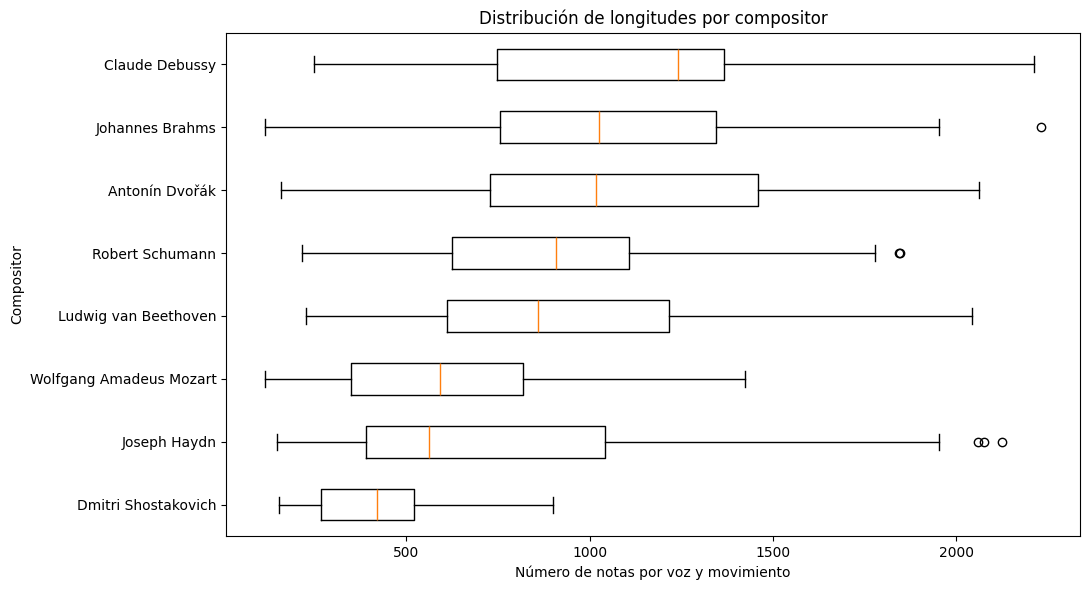

In [14]:
composer_order = (
    voice_movements.groupby("composer")["n_notes"]
    .median()
    .sort_values()
    .index
)

boxplot_data = [
    voice_movements.loc[
        voice_movements["composer"] == composer,
        "n_notes",
    ].to_numpy()
    for composer in composer_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(boxplot_data, labels=composer_order, vert=False)
plt.xlabel("Número de notas por voz y movimiento")
plt.ylabel("Compositor")
plt.title("Distribución de longitudes por compositor")
plt.tight_layout()
plt.show()

## 9. Longitud según número de movimiento

El número de movimiento no identifica automáticamente una forma o tempo
específico, pero permite examinar si ciertas posiciones dentro de la obra tienden
a ser más largas o más cortas.

,n_series,min_length,median_length,mean_length,max_length
movement_no,,,,,
1,116,246,1168.5,1198.681034,2231
2,116,137,530.0,591.000000,1289
3,116,114,493.5,552.060345,1639
4,116,262,955.5,1028.422414,2212


C:\Users\PC BULLOCK\AppData\Local\Temp\ipykernel_9144\2823910023.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


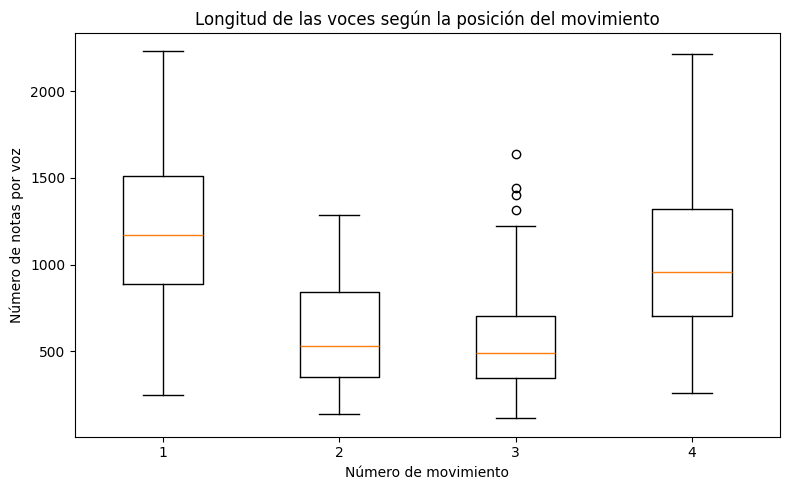

In [15]:
movement_number_summary = (
    voice_movements.groupby("movement_no")
    .agg(
        n_series=("n_notes", "size"),
        min_length=("n_notes", "min"),
        median_length=("n_notes", "median"),
        mean_length=("n_notes", "mean"),
        max_length=("n_notes", "max"),
    )
)

display(movement_number_summary)

movement_order = sorted(voice_movements["movement_no"].unique())
movement_boxplot_data = [
    voice_movements.loc[
        voice_movements["movement_no"] == movement_no,
        "n_notes",
    ].to_numpy()
    for movement_no in movement_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(
    movement_boxplot_data,
    labels=[str(number) for number in movement_order],
)
plt.xlabel("Número de movimiento")
plt.ylabel("Número de notas por voz")
plt.title("Longitud de las voces según la posición del movimiento")
plt.tight_layout()
plt.show()

## 10. Comparación entre instrumentos

La longitud de una voz mide el número de eventos de nota. Puede funcionar como
una medida preliminar de actividad instrumental, pero no debe confundirse con
duración temporal o importancia musical.

Se comparan:

- violín I;
- violín II;
- viola;
- cello.

,n_series,min_length,median_length,mean_length,max_length,mean_pitch,mean_pitch_range
voice_role,,,,,,,
vln_I,116,202,904.0,1007.698276,2231,74.297805,35.465517
vln_II,116,142,800.5,859.568966,2053,67.400690,28.275862
viola,116,148,772.0,828.474138,2212,60.830395,27.456897
cello,116,114,617.0,674.422414,1846,50.908805,32.362069


C:\Users\PC BULLOCK\AppData\Local\Temp\ipykernel_9144\2413813916.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(role_boxplot_data, labels=VOICE_ROLES)


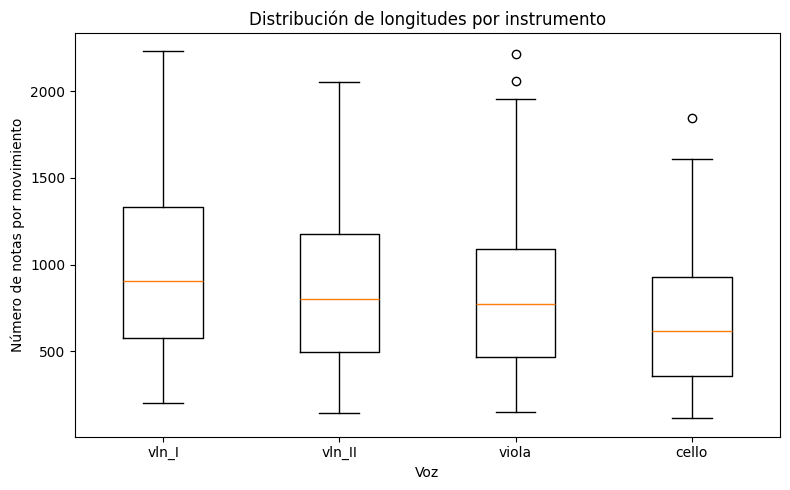

In [16]:
role_summary = (
    voice_movements.groupby("voice_role")
    .agg(
        n_series=("n_notes", "size"),
        min_length=("n_notes", "min"),
        median_length=("n_notes", "median"),
        mean_length=("n_notes", "mean"),
        max_length=("n_notes", "max"),
        mean_pitch=("pitch_mean", "mean"),
        mean_pitch_range=("pitch_range", "mean"),
    )
    .reindex(VOICE_ROLES)
)

display(role_summary)

role_boxplot_data = [
    voice_movements.loc[
        voice_movements["voice_role"] == role,
        "n_notes",
    ].to_numpy()
    for role in VOICE_ROLES
]

plt.figure(figsize=(8, 5))
plt.boxplot(role_boxplot_data, labels=VOICE_ROLES)
plt.xlabel("Voz")
plt.ylabel("Número de notas por movimiento")
plt.title("Distribución de longitudes por instrumento")
plt.tight_layout()
plt.show()

## 11. Movimientos extremos

Se identifican los movimientos con:

- voz más corta más pequeña;
- voz más corta más grande;
- mayor desigualdad entre las cuatro voces;
- mayor longitud media.

In [17]:
columns_to_show = [
    "composer",
    "work_title",
    "catalogue",
    "movement_no",
    "min_voice_len",
    "max_voice_len",
    "mean_voice_len",
    "max_min_ratio",
]

print("Movimientos con menor longitud mínima:")
display(
    movement_lengths.nsmallest(10, "min_voice_len")[columns_to_show]
    .reset_index(drop=True)
)

print("Movimientos con mayor longitud mínima:")
display(
    movement_lengths.nlargest(10, "min_voice_len")[columns_to_show]
    .reset_index(drop=True)
)

print("Movimientos con mayor desigualdad entre voces:")
display(
    movement_lengths.nlargest(10, "max_min_ratio")[columns_to_show]
    .reset_index(drop=True)
)

Movimientos con menor longitud mínima:


,composer,work_title,catalogue,movement_no,min_voice_len,max_voice_len,mean_voice_len,max_min_ratio
0,Johannes Brahms,String Quartet Op. 51 No. 2,Op. 51 No. 2,3,114,789,585.50,6.921053
1,Wolfgang Amadeus Mozart,String Quartet K. 421,K. 421,3,114,240,165.75,2.105263
2,Wolfgang Amadeus Mozart,String Quartet K. 428,K. 428,3,125,424,303.25,3.392000
3,Wolfgang Amadeus Mozart,String Quartet K. 458,K. 458,2,137,230,198.50,1.678832
4,Joseph Haydn,String Quartet Op. 20 No. 4,Op. 20 No. 4,3,148,323,227.75,2.182432
5,Dmitri Shostakovich,"String Quartet No. 1, Op. 49",Op. 49,2,153,288,218.25,1.882353
6,Antonín Dvořák,String Quartet Op. 51,Op. 51,2,157,862,677.75,5.490446
7,Joseph Haydn,String Quartet Op. 20 No. 6,Op. 20 No. 6,3,187,421,257.00,2.251337
8,Wolfgang Amadeus Mozart,String Quartet K. 465,K. 465,3,190,396,317.75,2.084211
9,Wolfgang Amadeus Mozart,String Quartet K. 464,K. 464,2,203,335,254.50,1.650246


Movimientos con mayor longitud mínima:


,composer,work_title,catalogue,movement_no,min_voice_len,max_voice_len,mean_voice_len,max_min_ratio
0,Antonín Dvořák,String Quartet Op. 105,Op. 105,4,1607,2061,1920.00,1.282514
1,Ludwig van Beethoven,String Quartet Op. 18 No. 6,Op. 18 No. 6,1,1530,1967,1795.75,1.285621
2,Antonín Dvořák,String Quartet Op. 51,Op. 51,1,1511,2017,1739.25,1.334878
3,Robert Schumann,String Quartet Op. 41 No. 3,Op. 41 No. 3,4,1506,1844,1602.75,1.224436
4,Johannes Brahms,String Quartet Op. 51 No. 1,Op. 51 No. 1,1,1363,1953,1720.00,1.432869
5,Claude Debussy,String Quartet Op. 10,Op. 10,4,1260,2212,1698.75,1.755556
6,Claude Debussy,String Quartet Op. 10,Op. 10,1,1241,1566,1379.75,1.261886
7,Joseph Haydn,String Quartet Op. 20 No. 4,Op. 20 No. 4,1,1229,2074,1486.50,1.687551
8,Johannes Brahms,String Quartet Op. 67,Op. 67,1,1225,2231,1680.00,1.821224
9,Joseph Haydn,String Quartet Op. 20 No. 5,Op. 20 No. 5,1,1218,2058,1550.75,1.689655


Movimientos con mayor desigualdad entre voces:


,composer,work_title,catalogue,movement_no,min_voice_len,max_voice_len,mean_voice_len,max_min_ratio
0,Johannes Brahms,String Quartet Op. 51 No. 2,Op. 51 No. 2,3,114,789,585.50,6.921053
1,Antonín Dvořák,String Quartet Op. 51,Op. 51,2,157,862,677.75,5.490446
2,Ludwig van Beethoven,String Quartet Op. 18 No. 3,Op. 18 No. 3,4,361,1827,1258.25,5.060942
3,Ludwig van Beethoven,String Quartet Op. 18 No. 4,Op. 18 No. 4,3,225,780,473.75,3.466667
4,Wolfgang Amadeus Mozart,String Quartet K. 428,K. 428,3,125,424,303.25,3.392000
5,Ludwig van Beethoven,String Quartet Op. 18 No. 4,Op. 18 No. 4,4,262,872,619.25,3.328244
6,Antonín Dvořák,String Quartet Op. 96,Op. 96,2,331,1025,602.75,3.096677
7,Joseph Haydn,String Quartet Op. 20 No. 6,Op. 20 No. 6,2,231,711,443.75,3.077922
8,Joseph Haydn,String Quartet Op. 20 No. 3,Op. 20 No. 3,2,318,917,519.75,2.883648
9,Joseph Haydn,String Quartet Op. 20 No. 5,Op. 20 No. 5,3,303,770,436.50,2.541254


## 15. Inspección de una obra y movimiento específicos

Cambiar las tres variables siguientes permite examinar cualquier voz:

- `SELECTED_WORK_ID`;
- `SELECTED_MOVEMENT`;
- `SELECTED_VOICE_ROLE`.

In [28]:
SELECTED_WORK_ID = "debussy_op10"
SELECTED_MOVEMENT = 4
SELECTED_VOICE_ROLE = "cello"

selected = df.loc[
    (df["work_id"] == SELECTED_WORK_ID)
    & (df["movement_no"] == SELECTED_MOVEMENT)
]

if selected.empty:
    raise KeyError(
        f"No existe {SELECTED_WORK_ID}, movimiento {SELECTED_MOVEMENT}."
    )

selected = selected.iloc[0]

if SELECTED_VOICE_ROLE not in VOICE_ROLES:
    raise KeyError(
        f"Rol inválido. Opciones: {VOICE_ROLES}"
    )

voice_index = VOICE_ROLES.index(SELECTED_VOICE_ROLE)
selected_pitches = selected["voices"][voice_index]

inspection = pd.DataFrame([{
    "composer": selected["composer_canonical"],
    "work_title": selected["work_title"],
    "catalogue": selected["catalogue"],
    "movement_no": int(selected["movement_no"]),
    "voice_role": SELECTED_VOICE_ROLE,
    "n_notes": len(selected_pitches),
    "pitch_min": min(selected_pitches),
    "pitch_max": max(selected_pitches),
    "pitch_mean": np.mean(selected_pitches),
    "first_40_pitches": selected_pitches[:40],
}])

display(inspection)
print(selected_pitches)

,composer,work_title,catalogue,movement_no,voice_role,n_notes,pitch_min,pitch_max,pitch_mean,first_40_pitches
0,Claude Debussy,String Quartet Op. 10,Op. 10,4,cello,1356,36,72,53.162979,"[49, 44, 48, 47, 39, 41, 44, 47, 51, 53, 49, 44, 46, 47, 48, 49, 51, 52, 54, 55, 56, 54, 47, 52, 45, 54, 47, 52, 45,..."


[49, 44, 48, 47, 39, 41, 44, 47, 51, 53, 49, 44, 46, 47, 48, 49, 51, 52, 54, 55, 56, 54, 47, 52, 45, 54, 47, 52, 45, 44, 44, 59, 61, 59, 61, 59, 58, 56, 54, 53, 52, 51, 50, 49, 48, 51, 50, 49, 48, 47, 47, 47, 50, 46, 49, 45, 48, 44, 47, 50, 53, 56, 47, 50, 46, 49, 45, 48, 44, 47, 50, 53, 56, 50, 53, 49, 52, 48, 51, 50, 47, 44, 50, 53, 49, 52, 48, 51, 50, 47, 44, 52, 54, 50, 53, 49, 52, 48, 51, 54, 57, 60, 52, 54, 50, 53, 49, 52, 48, 51, 54, 57, 60, 60, 63, 59, 62, 57, 60, 62, 60, 62, 60, 62, 60, 62, 60, 62, 60, 62, 60, 63, 59, 62, 57, 60, 62, 60, 62, 60, 62, 60, 62, 60, 62, 60, 62, 63, 66, 62, 65, 60, 63, 65, 63, 65, 63, 65, 63, 65, 63, 65, 63, 65, 63, 66, 62, 65, 60, 63, 65, 63, 65, 63, 65, 63, 65, 63, 65, 63, 65, 66, 65, 64, 63, 62, 61, 60, 59, 60, 59, 58, 57, 56, 55, 54, 53, 54, 58, 52, 56, 51, 55, 54, 58, 52, 56, 51, 55, 54, 58, 52, 56, 51, 55, 50, 54, 49, 53, 48, 52, 47, 51, 46, 50, 45, 49, 44, 48, 44, 50, 49, 50, 49, 52, 50, 55, 52, 53, 50, 50, 49, 50, 49, 47, 46, 45, 46, 47, 48,

## 18. Conclusiones

1. El archivo contiene **116 movimientos** pertenecientes a **29 cuartetos**.
2. Cada obra tiene exactamente cuatro movimientos numerados del 1 al 4.
3. Cada movimiento contiene cuatro voces válidas:
   violín I, violín II, viola y cello.